In [10]:
!pip install opencv-python numpy imgbeddings psycopg2-binary pillow


In [11]:
!pip install -q "huggingface_hub==0.25.2" "transformers==4.46.3" "tokenizers==0.20.3"
!pip install -q imgbeddings onnxruntime pillow psycopg2-binary

In [12]:
import cv2
alg="/content/haarcascade_frontalface_default.xml"
haar_cascade= cv2.CascadeClassifier(alg)
file_name="/content/21xp-friends-mediumSquareAt3X.jpg"
img=cv2.imread(file_name,0)
gray_img=cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
faces=haar_cascade.detectMultiScale(
    gray_img,scaleFactor=1.05,minNeighbors=5,minSize=(100,100)
)
i=0
for x,y,w,h in faces:
  cropped_image=img[ y: y+h, x : x + w]
  target_file_name="stored-faces/"+str(i)+".jpg"
  cv2.imwrite(
      target_file_name,cropped_image,
      )
  i=i+1;

In [ ]:
import numpy as np
from imgbeddings import imgbeddings
from PIL import Image as PILImage
import psycopg2
import os

DATABASE_URL = os.getenv("DATABASE_URL")
conn=psycopg2.connect((DATABASE_URL))

ibed = imgbeddings()

for filename in os.listdir("/content/stored-faces"):

    img = PILImage.open("/content/stored-faces/" + filename).convert("RGB")

    embedding = ibed.to_embeddings(img)

    cur = conn.cursor()

    cur.execute(
        "INSERT INTO pictures values (%s,%s)",
        (filename, embedding[0].tolist())
    )

    print(filename)

conn.commit()

2.jpg
5.jpg
0.jpg
7.jpg
4.jpg
3.jpg
6.jpg
8.jpg
1.jpg


In [ ]:
file_name = "/content/Jeff-Bezos.jpg"

img = PILImage.open(file_name).convert("RGB")
ibed = imgbeddings()
embedding = ibed.to_embeddings(img)

print("Embedding created successfully")
print(embedding.shape)

Database result: ('1.jpg', '[0.53251886,-0.19347413,0.44336504,-0.6633019,0.15657465,-0.7727608,0.8861286,0.029159827,0.13602355,-0.45329925,0.09863807,0.13075405,-0.42046013,0.645254,0.89640623,1.1668596,1.2528733,0.29880244,-0.34959853,-0.4546208,-0.40741947,-0.11169344,-0.73580605,0.5653704,-0.17759778,-0.4231544,0.038560238,0.8020415,-0.08102031,-0.09316267,0.6851263,0.22522101,-0.04378946,0.5784205,0.1915728,-0.449407,-0.067870714,0.46173713,0.30391943,0.5383942,0.571198,-0.17393945,-0.69983333,0.29472756,-0.24612989,0.19095877,0.08712001,0.18948129,-0.12954757,0.28115028,-0.8839458,0.32703614,0.7190276,0.29659337,1.1533123,0.23879522,-0.28782332,-0.10371703,0.31737286,-1.3935617,-0.4022195,-0.6425487,0.8690535,0.05012577,-0.050746843,-0.23750463,-0.28665978,0.9172571,-0.69150543,-0.42368788,0.072422504,-0.47163522,0.6884136,-1.044382,0.038899496,-0.4509125,1.1494758,-0.26248202,-0.25129753,1.0519555,-0.35637715,-0.31140912,-0.00028290134,0.3212642,-1.6097754,0.13793969,-0.3108658

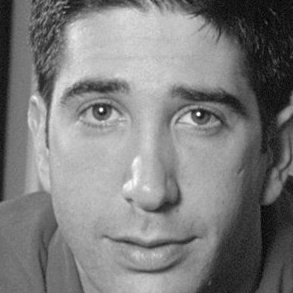

In [23]:
from IPython.display import Image as DisplayImage, display

cur = conn.cursor()

string_representation = "[" + ",".join(
    str(x) for x in embedding[0].tolist()
) + "]"

cur.execute(
    """
    SELECT * FROM pictures ORDER BY embedding <-> %s LIMIT 1;""",(string_representation,)
)

row = cur.fetchone()

print("Database result:", row)

if row is not None:
    image_path = "/content/stored-faces/" + row[0]

    print("Matched image:", image_path)

    display(DisplayImage(filename=image_path))
else:
    print("No image was returned from the database.")

cur.close()

In [21]:
conn.rollback()
print("Transaction reset")

Transaction reset


In [24]:
import os
import shutil

project_folder = "/content/face-recognition-project"

os.makedirs(project_folder, exist_ok=True)

In [25]:
shutil.copytree(
    "/content/stored-faces",
    project_folder + "/stored-faces",
    dirs_exist_ok=True
)

shutil.copy(
    "/content/Jeff-Bezos.jpg",
    project_folder + "/Jeff-Bezos.jpg"
)

shutil.copy(
    "/content/21xp-friends-mediumSquareAt3X.jpg",
    project_folder + "/21xp-friends-mediumSquareAt3X.jpg"
)
shutil.copy(
    "/content/haarcascade_frontalface_default.xml",
    project_folder + "/haarcascade_frontalface_default.xml"
)

'/content/face-recognition-project/haarcascade_frontalface_default.xml'

In [26]:
shutil.make_archive(
    "/content/face-recognition-project",
    "zip",
    project_folder
)

print("ZIP created!")

ZIP created!


In [27]:
from google.colab import files

files.download("/content/face-recognition-project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>